# Plotting mutation density vs depth for some genes

In [23]:
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sys.path.append('../../') 
from consensus_variables import *

In [25]:
all_mutrates = pd.read_table(f"../../data/bladder/all_mutdensities.tsv")

In [26]:
full_cohort_metadata = pd.read_table("../../data/bladder/20250516_metadata_bladder.with_depths.tsv")
full_cohort_metadata.head()

,SAMPLE_ID,SUBJECT_ID,AGE,SEX,BMI,SMOKING_STATUS,HISTORY_OF_SMOKING,CURRENT_SMOKER,ALCOHOL_GROUP,HISTORY_OF_DRINKING,...,NOTCH2_depth,FOXQ1_depth,CDKN1A_depth,KMT2C_depth,TP53_depth,RB1_depth,FGFR3_depth,PIK3CA_depth,TERTpromoter_depth,total_depth
0,P19_0047_BDO_01,P19_0047,46,M,29.9,former,yes,no,former,yes,...,6866.809023,4604.716364,12537.872222,8061.174839,10219.111423,7411.275842,10154.727518,8533.763889,1217.225989,7219.964358
1,P19_0009_BTR_01,P19_0009,56,F,32.8,current,yes,yes,heavy,yes,...,3582.336286,20081.660000,22902.629630,3906.232083,9616.333567,3643.054758,19295.271583,2809.628472,2877.779661,8327.585211
2,P19_0008_BDO_01,P19_0008,72,M,28.3,former,yes,no,occasional,yes,...,5380.276086,2035.886364,4938.668519,6636.928112,5494.578136,4971.831625,2959.359712,5894.118056,1441.333333,4372.224383
3,P19_0001_BTR_01,P19_0001,24,M,30.1,never,no,no,no,no,...,6541.577498,2180.124545,7210.483333,7638.135789,6367.466713,5440.150512,3755.018885,6841.708333,490.768362,5105.737962
4,P19_0041_BDO_01,P19_0041,59,F,52.7,never,no,no,NaN,NaN,...,4657.111403,2385.021818,5453.885185,5192.524296,4991.056762,5017.462665,4003.279676,5407.927083,1000.299435,4480.454219


In [27]:
subset_mutrates = all_mutrates[(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]
subset_mutrates_annotated = subset_mutrates.merge(full_cohort_metadata, on='SAMPLE_ID')
subset_mutrates_annotated.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSRATE_MB,...,NOTCH2_depth,FOXQ1_depth,CDKN1A_depth,KMT2C_depth,TP53_depth,RB1_depth,FGFR3_depth,PIK3CA_depth,TERTpromoter_depth,total_depth
0,P19_0007_BTR_01,ALL_GENES,all,SNV,553100541,241.0,275.0,0.435725,0.435725,0.497197,...,4472.958068,3004.605455,4551.298148,6139.920124,6555.826910,3965.061786,5519.119604,4985.871528,2621.920904,4573.389682
1,P19_0046_BTR_01,ALL_GENES,all,SNV,310723023,267.0,453.0,0.859286,0.859286,1.457890,...,2289.982701,10447.936364,6623.488889,3074.234080,1752.609671,3565.864422,5184.281475,2404.562500,299.774011,3142.133921
2,P19_0013_BTR_01,ALL_GENES,all,SNV,455742968,116.0,118.0,0.254529,0.254529,0.258918,...,3721.398699,1620.313636,4136.350000,4643.565565,3830.855641,4031.235139,2247.937050,4765.697917,353.288136,3516.711544
3,P19_0020_BTR_01,ALL_GENES,all,SNV,873942970,344.0,368.0,0.393618,0.393618,0.421080,...,7165.314974,3238.576364,6287.809259,8243.621034,7790.384022,6438.402050,5497.611511,8139.201389,1244.661017,6601.966740
4,P19_0009_BDO_01,ALL_GENES,all,SNV,498473418,469.0,1358.0,0.940873,0.940873,2.724318,...,3665.422225,1344.500909,3917.446296,4352.411360,5027.231955,3437.712445,3484.423561,3944.923611,512.870056,3675.478613


### Relationship with depth

In [28]:
subset_mutrates_all = all_mutrates[(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

# geness = [ 'ARID1A', 'CDKN1A', 'CREBBP',
#           'EP300', 'FGFR3', 'FOXQ1', 'KDM6A',
#           'KMT2C', 'KMT2D', 'NOTCH2', 'PIK3CA',
#           'RB1', 'RBM10', 'STAG2',
#           'TERTpromoter',
#           'TP53']

geness = [ #'ARID1A', 'CDKN1A', 'CREBBP',
        #   'EP300', 'FGFR3',
          'FOXQ1',
        #   'KDM6A',
        #   'KMT2C', 'KMT2D',
        'NOTCH2',
          'PIK3CA',
        #   'RB1',
        'RBM10',
        #'STAG2',
          'TERTpromoter',
          'TP53']

subset_mutrates_sel = all_mutrates[~(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               (all_mutrates["GENE"].isin(geness)) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

subset_mutrates_nosel = all_mutrates[~(all_mutrates["GENE"].isin(['ALL_GENES'])) &
                               ~(all_mutrates["GENE"].isin(geness)) &
                               (all_mutrates["SAMPLE_ID"].str.startswith("P19")) &
                               (all_mutrates["REGIONS"].isin(["all"])) &
                               (all_mutrates["MUTTYPES"].isin(['SNV']))
                              ]

In [29]:
subset_mutrates["GENE"].unique()

array(['ALL_GENES'], dtype=object)

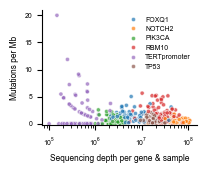

In [30]:
plt.figure(figsize = (2,1.5))
sns.scatterplot(data = subset_mutrates_sel,
                x = "DEPTH",
                y = "MUTDENSITY_MB",
                hue = "GENE",
                marker = '.',
                alpha = 0.7
               )
plt.xscale('log')

bottom, top = plt.ylim()
plt.ylim(-0.3, top)
sns.despine()


plt.legend(frameon=False, loc='upper right')
plt.xlabel("Sequencing depth per gene & sample")
plt.ylabel("Mutations per Mb")
plt.savefig('plots/mutdensity_depth_selected_genes.pdf', bbox_inches = 'tight', dpi = 300)
plt.show()